In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('weather_data_archive_april30.csv')
print(df.head())

             Timestamp  Temperature  Humidity  Wet_Bulb
0  2026-04-29 22:59:24         25.9      78.0     22.91
1  2026-04-29 23:00:20         25.8      79.0     22.96
2  2026-04-29 23:01:22         26.2      78.0     23.20
3  2026-04-29 23:25:14         26.5      75.0     23.06
4  2026-04-29 23:26:16         26.6      76.0     23.30


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    1380 non-null   str    
 1   Temperature  1380 non-null   float64
 2   Humidity     1380 non-null   float64
 3   Wet_Bulb     1380 non-null   float64
dtypes: float64(3), str(1)
memory usage: 43.3 KB


In [21]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    1380 non-null   datetime64[us]
 1   Temperature  1380 non-null   float64       
 2   Humidity     1380 non-null   float64       
 3   Wet_Bulb     1380 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 43.3 KB


In [23]:
# df = df.drop_duplicates(subset=['Timestamp'])

In [24]:
# print(df.info())

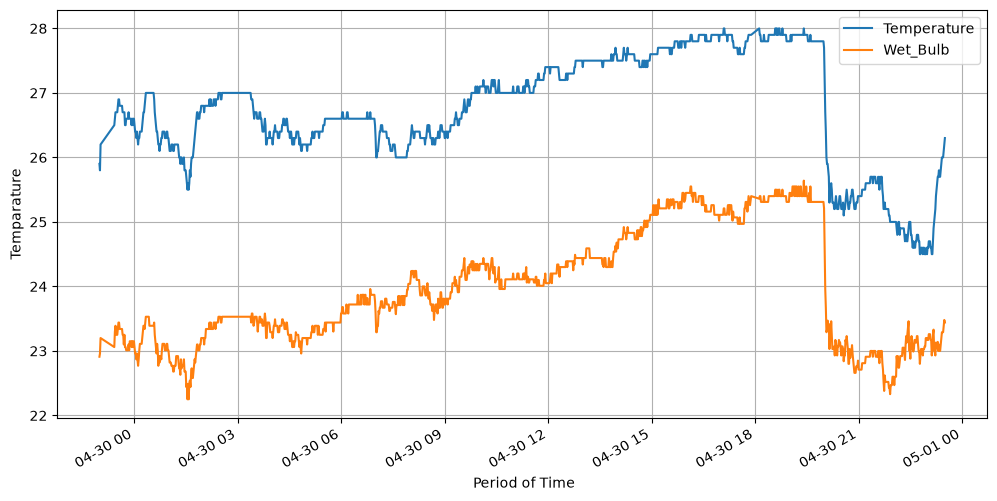

In [25]:
df.set_index('Timestamp', inplace=True)
df[["Temperature", "Wet_Bulb"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp and wet bulb", dpi=300)
plt.grid(True)
plt.show()

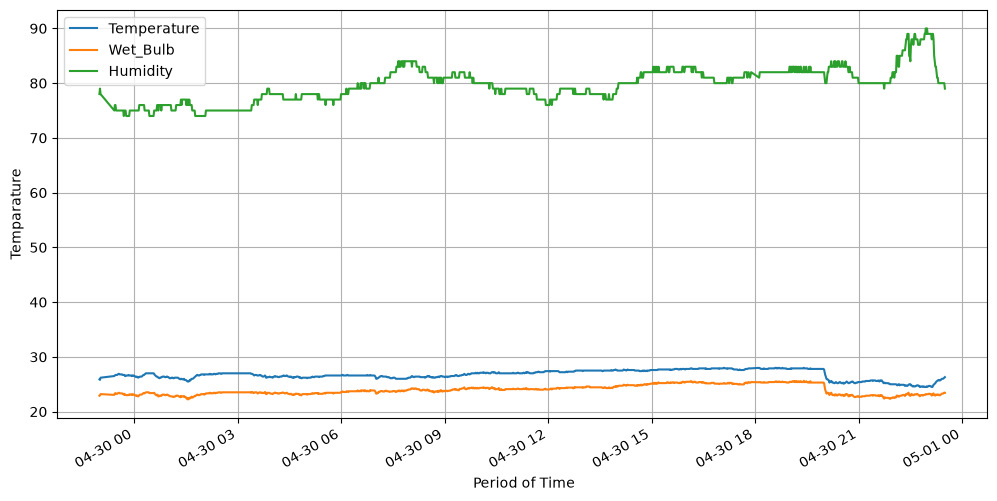

In [26]:
df[["Temperature", "Wet_Bulb", "Humidity"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp, humidity and wet bulb", dpi=300)
plt.grid(True)
plt.show()

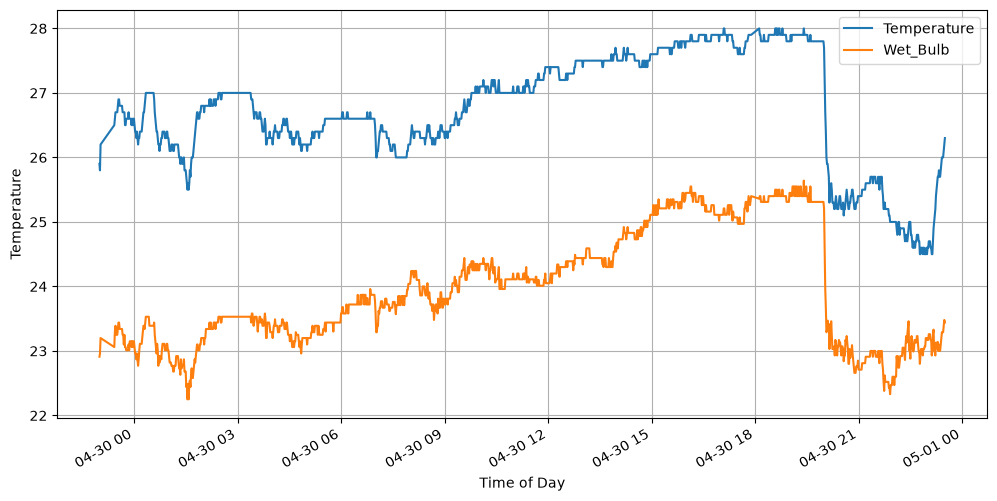

In [27]:
# 1. Set the index first (inplace=True makes sure it saves to the 'df' variable)
# df.set_index('Timestamp', inplace=True)

# 2. Now plot. Pandas will see the index is a 'datetime' and use it for the X-axis
df[["Temperature", "Wet_Bulb"]].plot(figsize=(12, 6))

# 3. Standard formatting
plt.xlabel("Time of Day") # Updated label to reflect actual time
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

In [28]:
print(df.head(),"\n\n")
df.info()

                     Temperature  Humidity  Wet_Bulb
Timestamp                                           
2026-04-29 22:59:24         25.9      78.0     22.91
2026-04-29 23:00:20         25.8      79.0     22.96
2026-04-29 23:01:22         26.2      78.0     23.20
2026-04-29 23:25:14         26.5      75.0     23.06
2026-04-29 23:26:16         26.6      76.0     23.30 


<class 'pandas.DataFrame'>
DatetimeIndex: 1380 entries, 2026-04-29 22:59:24 to 2026-04-30 23:29:50
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1380 non-null   float64
 1   Humidity     1380 non-null   float64
 2   Wet_Bulb     1380 non-null   float64
dtypes: float64(3)
memory usage: 43.1 KB


In [29]:
df_resampled = df.resample('5min').mean()
df_resampled.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 295 entries, 2026-04-29 22:55:00 to 2026-04-30 23:25:00
Freq: 5min
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  289 non-null    float64
 1   Humidity     289 non-null    float64
 2   Wet_Bulb     289 non-null    float64
dtypes: float64(3)
memory usage: 9.2 KB


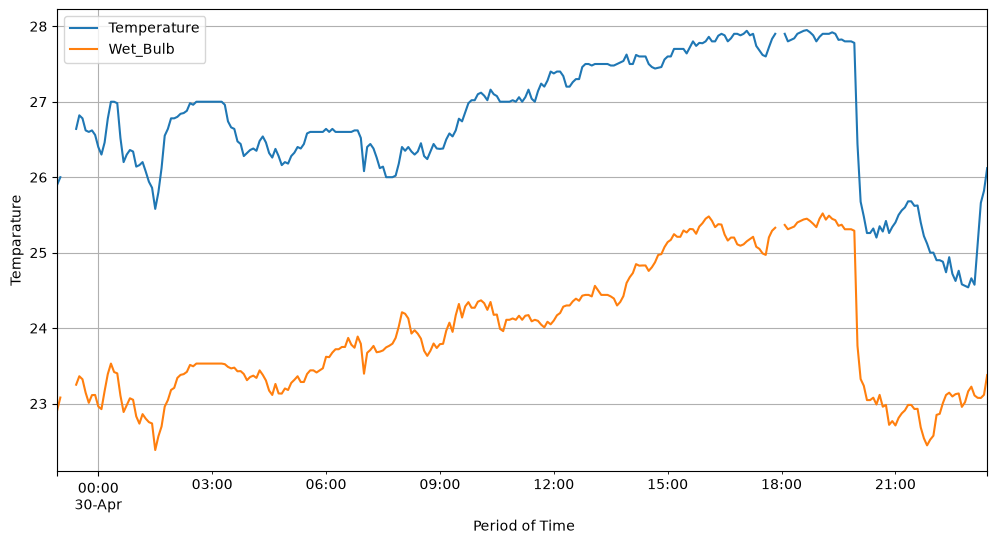

In [30]:
# df.set_index('Timestamp', inplace=True)
df_resampled[["Temperature", "Wet_Bulb"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp and wet bulb", dpi=300)
plt.grid(True)
plt.show()

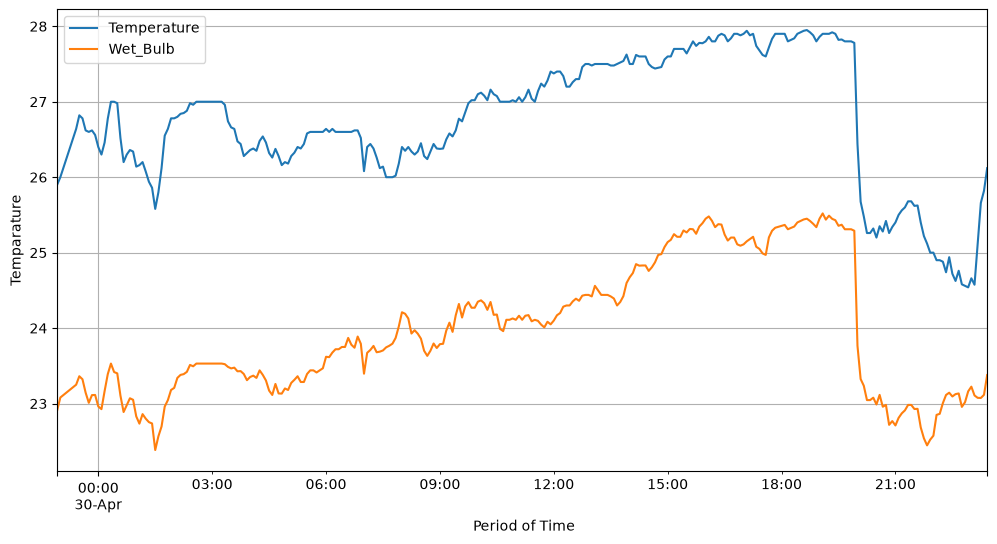

In [31]:
df_resampled = df_resampled.interpolate(method='time', limit=4)
# df.set_index('Timestamp', inplace=True)

df_resampled[["Temperature", "Wet_Bulb"]].plot(figsize = (12, 6))
plt.xlabel(" Period of Time")
plt.ylabel("Temparature")
# plt.savefig("Graph Temp vs Period of Time of both room temp and wet bulb", dpi=300)
plt.grid(True)
plt.show()

In [32]:
df_resampled['WB_rolling_15min'] = df_resampled['Wet_Bulb'].rolling(3).mean()
df_resampled.info()
print("\n\n",df_resampled.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 295 entries, 2026-04-29 22:55:00 to 2026-04-30 23:25:00
Freq: 5min
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       295 non-null    float64
 1   Humidity          295 non-null    float64
 2   Wet_Bulb          295 non-null    float64
 3   WB_rolling_15min  293 non-null    float64
dtypes: float64(4)
memory usage: 11.5 KB


                      Temperature  Humidity  Wet_Bulb  WB_rolling_15min
Timestamp                                                             
2026-04-29 22:55:00       25.900     78.00    22.910               NaN
2026-04-29 23:00:00       26.000     78.50    23.080               NaN
2026-04-29 23:05:00       26.128     77.88    23.114         23.034667
2026-04-29 23:10:00       26.256     77.26    23.148         23.114000
2026-04-29 23:15:00       26.384     76.64    23.182         23.148000


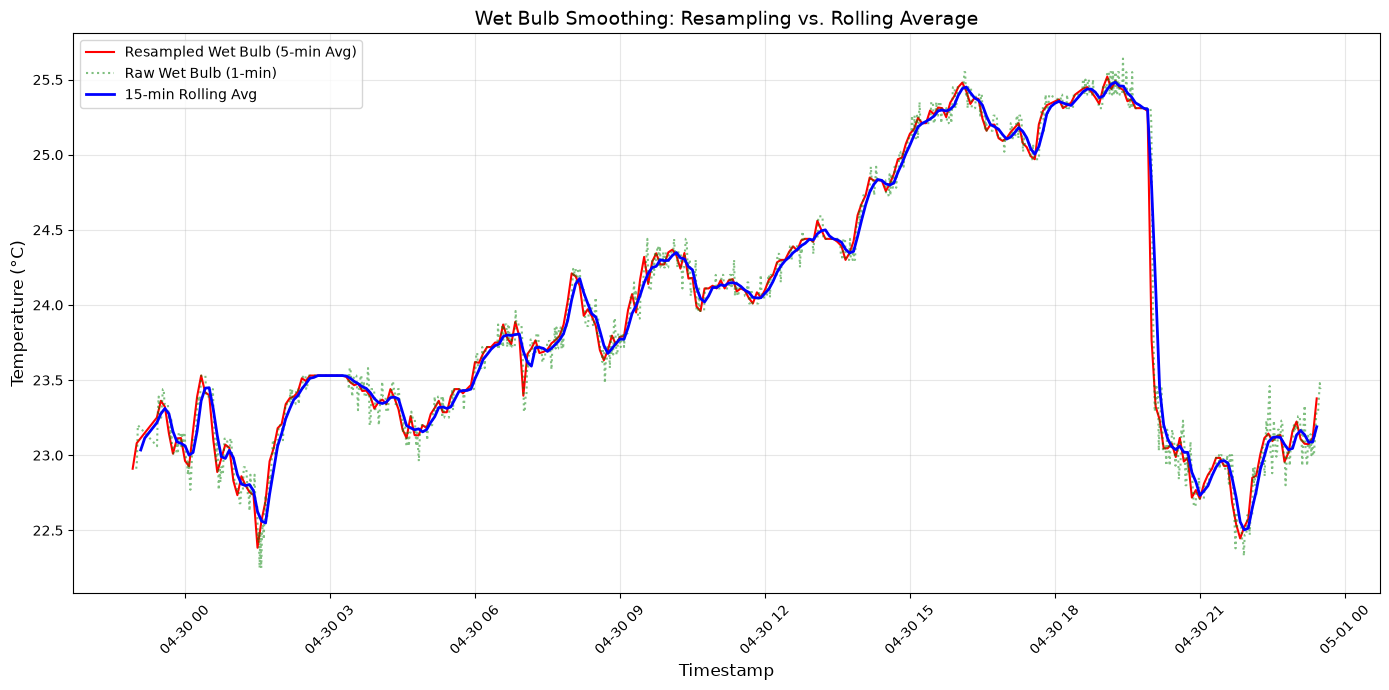

In [33]:
plt.figure(figsize=(14, 7))
plt.plot(df_resampled.index, df_resampled['Wet_Bulb'], label='Resampled Wet Bulb (5-min Avg)', color='red', linewidth=1.5)
plt.plot(df.index, df['Wet_Bulb'], label='Raw Wet Bulb (1-min)', color='green', alpha=0.5, linestyle=':')
plt.plot(df_resampled.index, df_resampled['WB_rolling_15min'], label='15-min Rolling Avg', color='blue', linewidth=2)

plt.title('Wet Bulb Smoothing: Resampling vs. Rolling Average', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# plt.savefig('resampled_rolling_analysis.png')
plt.show()

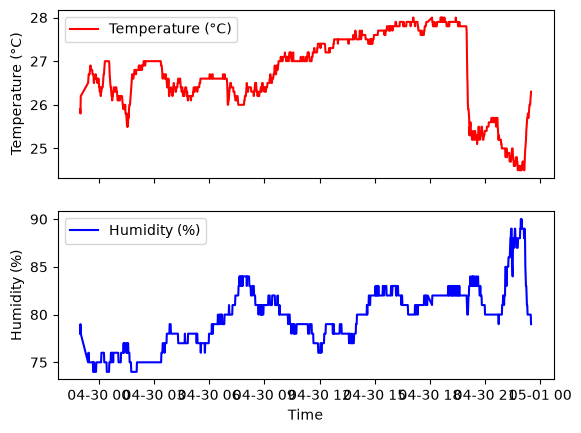

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(df.index, df['Temperature'], 'r-', label='Temperature (°C)')
ax1.set_ylabel('Temperature (°C)')
ax1.legend()

ax2.plot(df.index, df['Humidity'], 'b-', label='Humidity (%)')
ax2.set_ylabel('Humidity (%)')
ax2.set_xlabel('Time')
ax2.legend()